# Constrained Bayesian linear regression

The paper's Section 3.2 experiment, run with the paper's own $J$ fields and with anchored Langevin.
Data model exactly as their Eq. (3.8):

$$\delta_j\sim\mathcal N(0,0.25),\qquad a_j\sim\mathcal N\bigl(2\cdot\mathbf 1,\tfrac12 I_3\bigr),\qquad
y_j=x_*^\top a_j+\delta_j,\qquad x_*=[1,-0.7,-0.5]^\top,$$

with $n=10^5$ observations, minibatch size $m=50$, uniform prior on $K$, and the constraint sets
$K=\{\lVert x\rVert_2^2\le1\}$ and the smoothed $\ell_p$ ball $\{g\le\lambda\}$, $p=4,\varepsilon=0.2,\lambda=1$.

Note $\lVert x_*\rVert=1.32>1$: **the truth lies outside the constraint set**, so the constraint is active
and the posterior piles up toward the boundary in the direction of $x_*$. Its projection onto $K$ is
$[0.758,-0.530,-0.380]$.

## One modelling choice has to be made explicit

The paper writes the target with a *sum* over data, $\mu\propto\exp\bigl(-\frac12\sum_j(y_j-x^\top a_j)^2\bigr)$,
but its SGLD uses the *average* gradient $\nabla f=\frac1n\sum_i\nabla f_i$ (their Eq. 3.9 and the text
below it). Those two are not the same target, and with $n=10^5$ the difference is drastic — so this
notebook writes the target with an explicit inverse temperature and reports what each regime looks like:

$$\mu(x)\;\propto\;\exp\Bigl(-\frac{\beta}{2n}\sum_{j=1}^n\bigl(y_j-x^\top a_j\bigr)^2\Bigr)\mathbf 1_K .$$

* $\beta=1$ (their gradient convention taken literally): posterior s.d. $\approx1.17$, wider than $K$ itself.
  The constrained mean is $[0.06,-0.12,-0.10]$ against a truth of $[1,-0.7,-0.5]$ — the data is washed out
  and the target is essentially uniform on $K$.
* $\beta=n$ (their written target): posterior s.d. $\approx0.004$, a point mass at the boundary. Nothing to
  compare, and rejection sampling for a reference is infeasible.
* $\beta=32$ (used here): s.d. $\approx0.21$, constrained mean $[0.63,-0.48,-0.35]$ — informative about
  $x_*$, visibly spread inside $K$, pushed against the boundary, and rejection-samplable (6% acceptance) so
  an **exact reference** is available. Experiment 2 shows the whole range.

Because the potential is quadratic in $x$, the anchor recipe returns $U_0=U$ and $\Delta\equiv0$: the
anchored scheme *is* SGLD plus the skew term here. Experiment 5 adds a Bayesian **Lasso** prior, which is
non-differentiable, and there the anchoring does real work.

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance

In [2]:
# -----------------------------
# Data, exactly the paper's Eq. (3.8)
# -----------------------------
d       = 3
n_data  = 100_000
BATCH   = 50
BETA    = 32.0
N       = 5000          # particles
max_iter= 20000
eta     = 1e-4
TRACK_EVERY = 10
SEED    = 1006
LAM     = 1.0
P_LP, EPS_LP = 4.0, 0.2

rng = np.random.default_rng(SEED)
x_star = np.array([1.0, -0.7, -0.5])
A = rng.normal(2.0, np.sqrt(0.5), size=(n_data, d))
Y = A @ x_star + rng.normal(0.0, np.sqrt(0.25), size=n_data)

H = A.T @ A / n_data
bvec = A.T @ Y / n_data
mu_ols = np.linalg.solve(H, bvec)

At = torch.tensor(A); Yt = torch.tensor(Y)
Ht = torch.tensor(H); bt = torch.tensor(bvec)

print("||x*||        = {:.4f}   (outside K: {})".format(np.linalg.norm(x_star), np.linalg.norm(x_star) > 1))
print("OLS           =", np.round(mu_ols, 4))
print("proj of OLS   =", np.round(mu_ols / np.linalg.norm(mu_ols), 4))
print("H eigenvalues =", np.round(np.linalg.eigvalsh(H), 3), " -> beta*lam_max*eta =", round(BETA*12.515*eta, 3))

||x*||        = 1.3191   (outside K: True)
OLS           = [ 0.9993 -0.698  -0.5005]
proj of OLS   = [ 0.7584 -0.5297 -0.3798]
H eigenvalues = [ 0.493  0.5   12.515]  -> beta*lam_max*eta = 0.04


In [3]:
# -----------------------------
# Potential (average convention, tempered by BETA) and its gradients
#   U(x) = (beta/2) (x-OLS)' H (x-OLS) + const
# full gradient and the minibatch estimator of the paper's Eq. (3.9)
# -----------------------------
@torch.no_grad()
def grad_U_full(x):
    return BETA * ((x - torch.tensor(mu_ols)) @ Ht.T)

@torch.no_grad()
def grad_U_batch(x, gen):
    idx = torch.randint(0, n_data, (BATCH,), generator=gen)
    Ab, Yb = At[idx], Yt[idx]                       # (m,d), (m,)
    resid = x @ Ab.T - Yb                           # (N,m)
    return BETA * (resid @ Ab) / BATCH

# -----------------------------
# Constraint sets and projections
# -----------------------------
def g_ball(x):      return torch.sum(x * x, dim=1)
def grad_g_ball(x): return 2 * x
def g_lp(x):        return torch.sum((x * x + EPS_LP ** 2) ** (P_LP / 2), dim=1)
def grad_g_lp(x):   return P_LP * x * (x * x + EPS_LP ** 2) ** (P_LP / 2 - 1)

@torch.no_grad()
def proj_ball(x):
    nn = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(np.sqrt(LAM) / nn, max=1.0)

@torch.no_grad()
def proj_lp(x, iters=15):
    x = x.clone()
    for _ in range(iters):
        gv = g_lp(x); m = gv > LAM
        if not m.any(): break
        gg = grad_g_lp(x[m])
        x[m] = x[m] - ((gv[m] - LAM) / (gg.norm(dim=1) ** 2 + 1e-12)).unsqueeze(1) * gg
    gv = g_lp(x); m = gv > LAM
    if m.any():
        xm = x[m]; lo = torch.zeros(xm.shape[0]); hi = torch.ones(xm.shape[0])
        for _ in range(40):
            mid = (lo + hi) / 2
            over = g_lp(xm * mid.unsqueeze(1)) > LAM
            hi = torch.where(over, mid, hi); lo = torch.where(over, lo, mid)
        x[m] = xm * lo.unsqueeze(1)
    return x

PROJ = {"ball": proj_ball, "lp": proj_lp}
GFUN = {"ball": g_ball,    "lp": g_lp}

# -----------------------------
# Skew fields: the paper's Eq. (3.1) constant J_a, and k = grad[(lam-g)h] with h = 1
# -----------------------------
def J_const_mat(a):
    return torch.diag(a * torch.ones(d - 1), diagonal=1) + torch.diag(-a * torch.ones(d - 1), diagonal=-1)

@torch.no_grad()
def skew_apply(x, v, field, s, setname):
    if field == "none":  return torch.zeros_like(v)
    if field == "const": return v @ J_const_mat(s).T
    k = -s * (grad_g_ball(x) if setname == "ball" else grad_g_lp(x))     # k = grad[(lam - g)]
    return torch.cross(k, v, dim=1)

In [4]:
# -----------------------------
# Exact reference: Gaussian(OLS, (beta H)^-1) truncated to K, by rejection
# -----------------------------
Sig = np.linalg.inv(BETA * H); Lsig = np.linalg.cholesky(Sig)
print("posterior s.d. (unconstrained):", np.round(np.sqrt(np.diag(Sig)), 3))

def sample_posterior(setname, n, rng):
    out = []
    while len(out) < n:
        z = mu_ols + rng.normal(size=(20000, d)) @ Lsig.T
        ok = GFUN[setname](torch.tensor(z)).numpy() <= LAM
        out.extend(z[ok].tolist())
    return np.array(out[:n])

def w1_floor(ref, setname, rng, reps=8):
    return [float(np.mean([wasserstein_distance(ref[:, i], sample_posterior(setname, len(ref), rng)[:, i])
                           for _ in range(reps)])) for i in range(d)]

refs, floors, mse_floor = {}, {}, {}
for setname in ["ball", "lp"]:
    refs[setname] = sample_posterior(setname, N, rng)
    floors[setname] = w1_floor(refs[setname], setname, rng)
    mse_floor[setname] = float(np.mean(np.sum((refs[setname] - x_star) ** 2, axis=1)))
    print("{:<5} constrained mean {}   W1 floor {}   MSE floor {:.4f}".format(
        setname, np.round(refs[setname].mean(0), 3), np.round(floors[setname], 4), mse_floor[setname]))

posterior s.d. (unconstrained): [0.207 0.207 0.206]


ball  constrained mean [ 0.631 -0.475 -0.35 ]   W1 floor [0.0029 0.0026 0.0032]   MSE floor 0.2639


lp    constrained mean [ 0.754 -0.545 -0.409]   W1 floor [0.0023 0.0043 0.0042]   MSE floor 0.1579


In [5]:
# -----------------------------
# SRNSGLD / PSGLD:  x <- P_K( x - eta (I + J(x)) gradU_hat + sqrt(2 eta) xi )
# -----------------------------
def run_chain(setname, field, s, stochastic=True, eta=eta, n_steps=max_iter, N=N,
              ref=None, seed=SEED, track=True):
    proj = PROJ[setname]
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    x = proj(torch.zeros(N, d))
    W, MSE = [], []
    xs_t = torch.tensor(x_star)
    for _it in range(n_steps):
        g = grad_U_batch(x, gen) if stochastic else grad_U_full(x)
        drift = g + skew_apply(x, g, field, s, setname)
        x = proj(x - eta * drift + np.sqrt(2 * eta) * torch.randn_like(x))
        MSE.append(float(torch.mean(torch.sum((x - xs_t) ** 2, dim=1))))
        if track and (_it % TRACK_EVERY == 0):
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), (np.array(W) if track else None), np.array(MSE)

def on_boundary(setname, X):
    return float(np.mean(GFUN[setname](torch.tensor(X)).numpy() > 0.999 * LAM))

## Experiment 1 — ball constraint: PSGLD vs SRNSGLD($J_a$) vs SRNSGLD($J_s$)

The paper's parameters: $a=1$ for the constant field, $s=5$ for the state-dependent one.

In [6]:
METHODS = [("none", 0.0, "PSGLD (J = 0)"),
           ("const", 1.0, "SRNSGLD ($J_a$, a = 1)"),
           ("state", 5.0, "SRNSGLD ($J_s$, s = 5)")]
COL = {"PSGLD (J = 0)": "#55A868", "SRNSGLD ($J_a$, a = 1)": "#4C72B0", "SRNSGLD ($J_s$, s = 5)": "#DD8452"}

exp1 = {}
for field, s, lab in METHODS:
    xf, W, mse = run_chain("ball", field, s, ref=refs["ball"])
    exp1[lab] = {"x": xf, "W1": W, "mse": mse}
    print("{:<26} MSE {:.4f}   W1 {}   on-boundary {:.3f}".format(
        lab.replace("$", ""), mse[-100:].mean(), np.round(W[-100:].mean(axis=0), 4), on_boundary("ball", xf)))
print("{:<26} MSE {:.4f}   W1 {}   on-boundary {:.3f}".format(
    "exact posterior", mse_floor["ball"], np.round(floors["ball"], 4), on_boundary("ball", refs["ball"])))

PSGLD (J = 0)              MSE 0.2580   W1 [0.0045 0.0041 0.005 ]   on-boundary 0.074


SRNSGLD (J_a, a = 1)       MSE 0.2588   W1 [0.0127 0.1437 0.121 ]   on-boundary 0.149


SRNSGLD (J_s, s = 5)       MSE 0.2591   W1 [0.0143 0.0277 0.0281]   on-boundary 0.094
exact posterior            MSE 0.2639   W1 [0.0029 0.0026 0.0032]   on-boundary 0.004


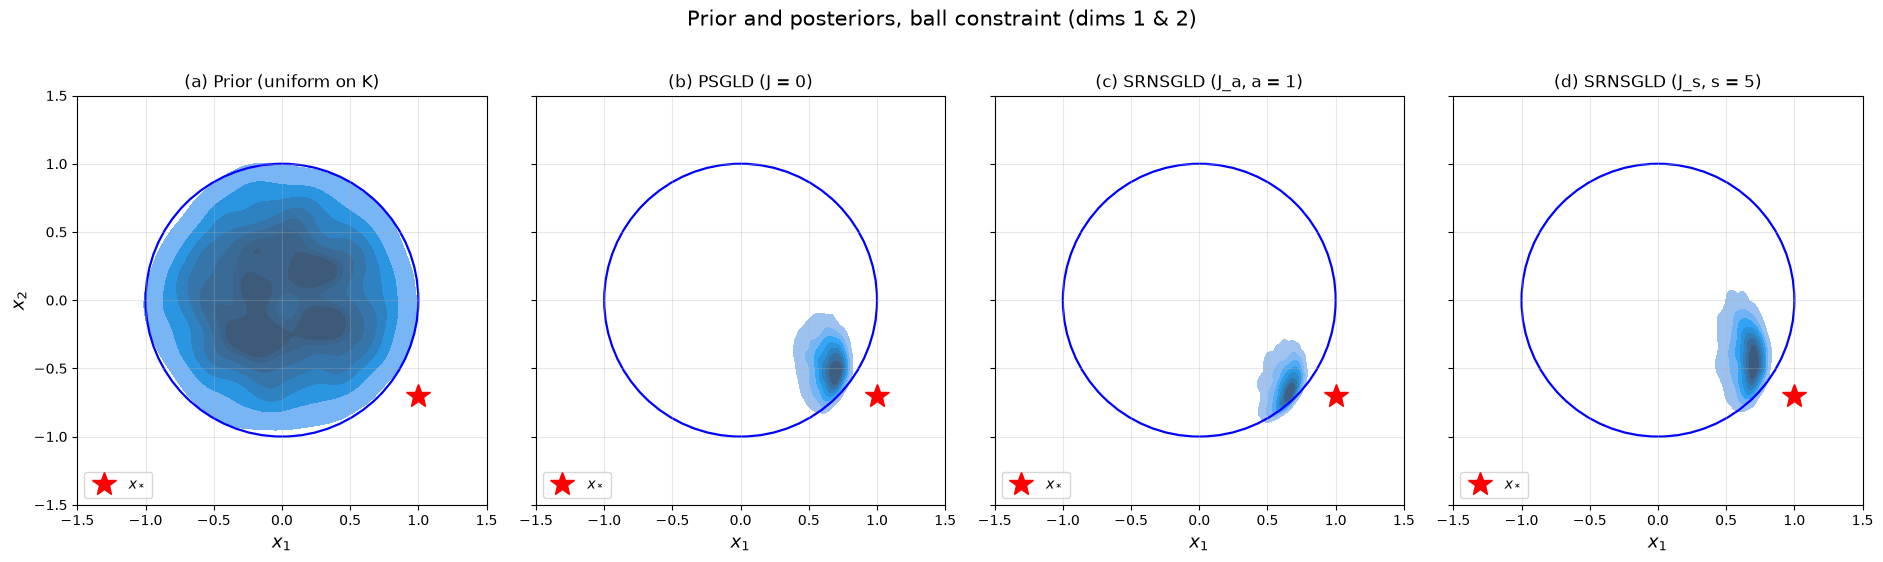

In [7]:
# ---- the paper's Figure 6: prior and the three posteriors, with the constraint and x*
rng_prior = np.random.default_rng(0)
zz = rng_prior.normal(size=(N, d)); zz /= np.linalg.norm(zz, axis=1, keepdims=True)
prior = zz * rng_prior.uniform(size=(N, 1)) ** (1 / d)        # uniform on the ball = the prior

panels = [("(a) Prior (uniform on K)", prior)] + [("({}) {}".format(c, lab), exp1[lab]["x"])
                                                  for c, (_, _, lab) in zip("bcd", METHODS)]
fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=True, sharey=True)
for ax, (name, X) in zip(axes, panels):
    sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
    ax.add_patch(Circle((0, 0), np.sqrt(LAM), edgecolor="b", facecolor="none", linewidth=1.6))
    ax.plot([x_star[0]], [x_star[1]], "r*", markersize=18, label="$x_*$")
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_title(name.replace("$", ""), fontsize=12)
    ax.set_xlabel("$x_1$", fontsize=13); ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box"); ax.legend(fontsize=10, loc="lower left")
axes[0].set_ylabel("$x_2$", fontsize=13)
fig.suptitle("Prior and posteriors, ball constraint (dims 1 & 2)", fontsize=15, y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("figures/blr_ball_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

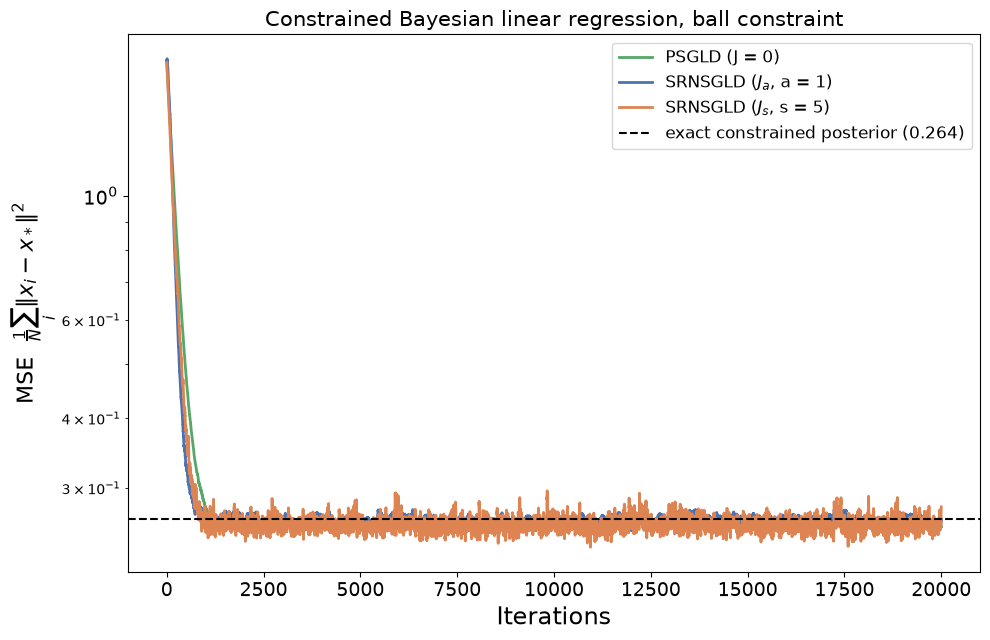

In [8]:
# ---- the paper's Figure 7: MSE against iteration
plt.figure(figsize=(10, 6.5))
for _, _, lab in METHODS:
    plt.plot(exp1[lab]["mse"], linewidth=2, color=COL[lab], label=lab)
plt.axhline(mse_floor["ball"], color="k", linestyle="--", linewidth=1.5,
            label="exact constrained posterior ({:.3f})".format(mse_floor["ball"]))
plt.yscale("log")
plt.xlabel("Iterations", fontsize=17); plt.ylabel(r"MSE  $\frac{1}{N}\sum_i\|x_i-x_*\|^2$", fontsize=16)
plt.title("Constrained Bayesian linear regression, ball constraint", fontsize=15)
plt.tick_params(labelsize=14); plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/blr_ball_mse.pdf", dpi=300, bbox_inches="tight")
plt.show()

### New: $W_1$ against the exact constrained posterior

MSE alone cannot distinguish "converged to the right distribution" from "collapsed onto the right point" —
and since $x_*\notin K$ the MSE floor is $0.26$, not $0$. An exact reference is available here by
rejection, so the same $W_1$ diagnostic used throughout this repo applies.

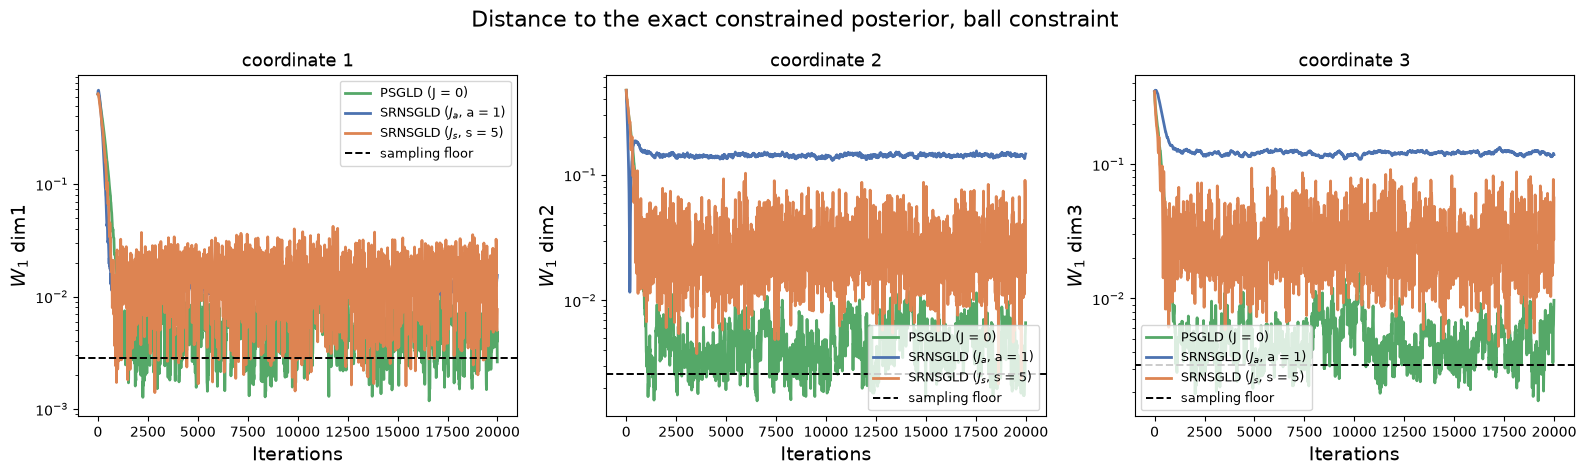

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for i, ax in enumerate(axes):
    for _, _, lab in METHODS:
        ax.plot(np.arange(len(exp1[lab]["W1"]))*TRACK_EVERY, exp1[lab]["W1"][:, i], linewidth=2, color=COL[lab], label=lab)
    ax.axhline(floors["ball"][i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
    ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
    ax.set_title("coordinate {}".format(i + 1), fontsize=13); ax.legend(fontsize=9)
fig.suptitle("Distance to the exact constrained posterior, ball constraint", fontsize=16)
plt.tight_layout()
plt.savefig("figures/blr_ball_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 2 — new: which $\beta$, and why it matters

The inverse temperature decides whether this experiment is about the data or about the constraint.

beta = 1.0    sd 1.171   constrained mean [ 0.069 -0.109 -0.108]   MSE 1.871   boundary 0.001
beta = 4.0    sd 0.586   constrained mean [ 0.303 -0.279 -0.213]   MSE 1.069   boundary 0.002


beta = 8.0    sd 0.414   constrained mean [ 0.449 -0.364 -0.276]   MSE 0.656   boundary 0.004
beta = 16.0   sd 0.293   constrained mean [ 0.556 -0.438 -0.313]   MSE 0.407   boundary 0.004
beta = 32.0   sd 0.207   constrained mean [ 0.627 -0.475 -0.346]   MSE 0.269   boundary 0.009
beta = 64.0   sd 0.146   constrained mean [ 0.674 -0.502 -0.368]   MSE 0.190   boundary 0.017
beta = 128.0  sd 0.104   constrained mean [ 0.714 -0.529 -0.372]   MSE 0.140   boundary 0.035


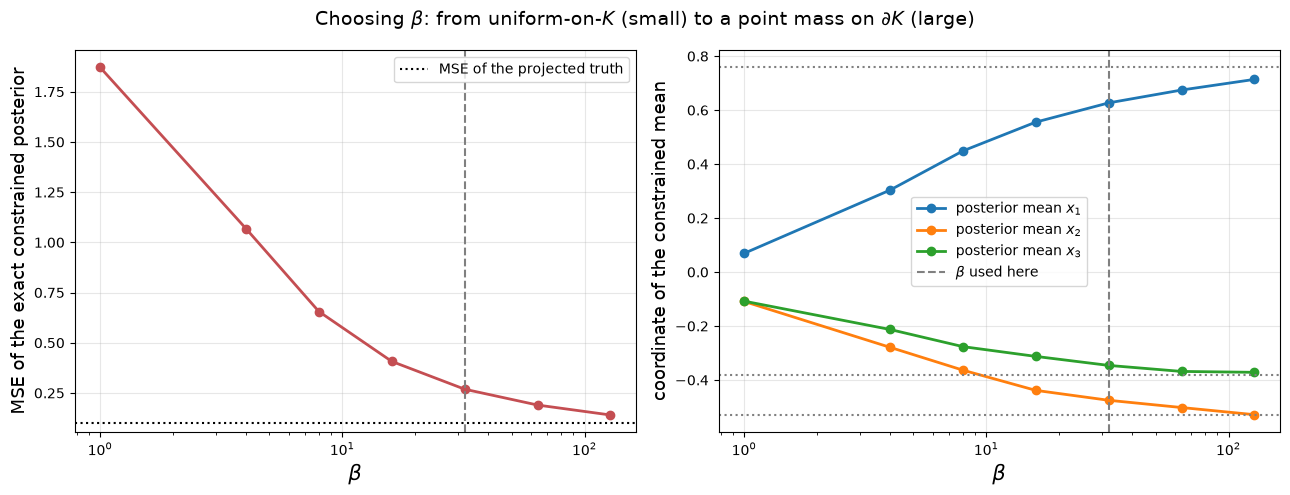

In [10]:
BETAS = [1.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0]
rows = []
for bta in BETAS:
    S = np.linalg.inv(bta * H); Lb = np.linalg.cholesky(S)
    out = []
    for _ in range(400):
        z = mu_ols + np.random.default_rng(int(bta) + 7).normal(size=(20000, d)) @ Lb.T
        out.extend(z[np.linalg.norm(z, axis=1) <= 1.0].tolist())
        if len(out) >= 4000: break
    r = np.array(out[:4000])
    rows.append((bta, np.sqrt(S[0, 0]), r.mean(0), np.mean(np.sum((r - x_star) ** 2, 1)),
                 np.mean(np.linalg.norm(r, axis=1) > 0.999)))
    print("beta = {:<6} sd {:.3f}   constrained mean {}   MSE {:.3f}   boundary {:.3f}".format(
        bta, rows[-1][1], np.round(rows[-1][2], 3), rows[-1][3], rows[-1][4]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(BETAS, [r[3] for r in rows], "-o", linewidth=2, color="#C44E52")
axes[0].axhline(np.sum(x_star ** 2) * 0 + np.sum((mu_ols / np.linalg.norm(mu_ols) - x_star) ** 2),
                color="k", linestyle=":", label="MSE of the projected truth")
axes[0].set_xscale("log"); axes[0].set_xlabel(r"$\beta$", fontsize=15)
axes[0].set_ylabel(r"MSE of the exact constrained posterior", fontsize=13)
axes[0].axvline(BETA, color="gray", linestyle="--"); axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)
for j, nm in enumerate(["$x_1$", "$x_2$", "$x_3$"]):
    axes[1].plot(BETAS, [r[2][j] for r in rows], "-o", linewidth=2, label="posterior mean " + nm)
    axes[1].axhline((mu_ols / np.linalg.norm(mu_ols))[j], linestyle=":", color="gray")
axes[1].set_xscale("log"); axes[1].set_xlabel(r"$\beta$", fontsize=15)
axes[1].set_ylabel("coordinate of the constrained mean", fontsize=13)
axes[1].axvline(BETA, color="gray", linestyle="--", label=r"$\beta$ used here")
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)
fig.suptitle(r"Choosing $\beta$: from uniform-on-$K$ (small) to a point mass on $\partial K$ (large)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/blr_beta.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 3 — new: does the stochastic gradient change the ranking?

The paper's framing is a stochastic-gradient one ($m=50$ out of $n=10^5$). Running the same three schemes
with the exact full gradient isolates what the minibatch noise contributes.

method                         MSE (batch) MSE (full grad)
----------------------------------------------------------


PSGLD (J = 0)                       0.2580          0.2584


SRNSGLD (J_a, a = 1)                0.2588          0.2616


SRNSGLD (J_s, s = 5)                0.2591          0.2574
exact posterior                     0.2639          0.2639


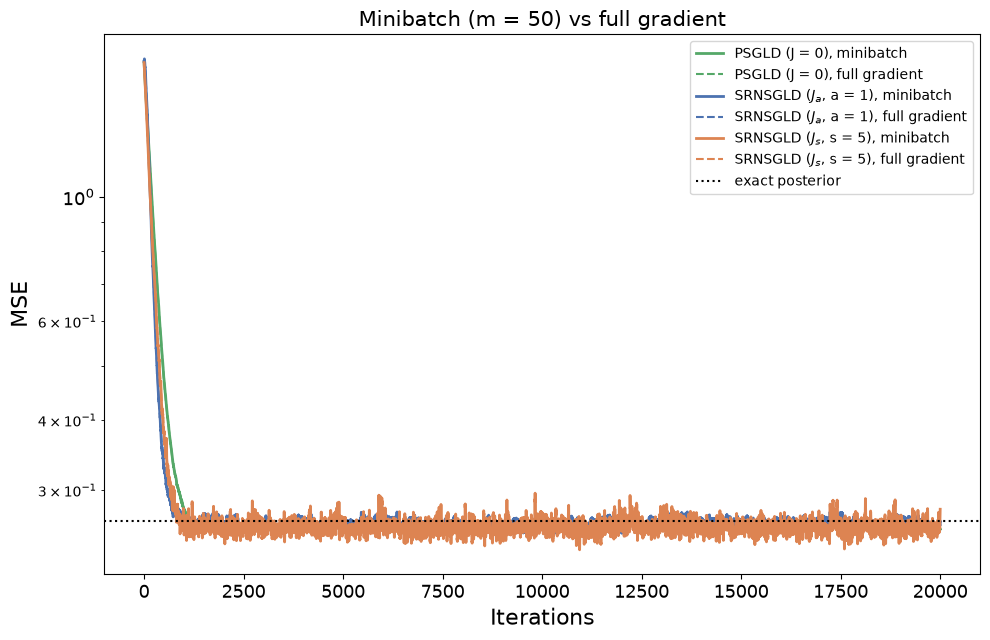

In [11]:
print("{:<26}{:>16}{:>16}".format("method", "MSE (batch)", "MSE (full grad)"))
print("-" * 58)
full = {}
for field, s, lab in METHODS:
    xf, _, mse = run_chain("ball", field, s, stochastic=False, ref=refs["ball"], track=False)
    full[lab] = mse
    print("{:<26}{:>16.4f}{:>16.4f}".format(lab.replace("$", ""), exp1[lab]["mse"][-100:].mean(), mse[-100:].mean()))
print("{:<26}{:>16.4f}{:>16.4f}".format("exact posterior", mse_floor["ball"], mse_floor["ball"]))

plt.figure(figsize=(10, 6.5))
for _, _, lab in METHODS:
    plt.plot(exp1[lab]["mse"], linewidth=2, color=COL[lab], label=lab + ", minibatch")
    plt.plot(full[lab], linewidth=1.5, linestyle="--", color=COL[lab], label=lab + ", full gradient")
plt.axhline(mse_floor["ball"], color="k", linestyle=":", linewidth=1.5, label="exact posterior")
plt.yscale("log"); plt.xlabel("Iterations", fontsize=16); plt.ylabel("MSE", fontsize=16)
plt.title("Minibatch (m = 50) vs full gradient", fontsize=15)
plt.tick_params(labelsize=13); plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/blr_batch_vs_full.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 4 — smoothed $\ell_p$ ball constraint

The paper's second constraint set for this model, with the state-dependent field built from
$k=\nabla(\lambda-g)$ as in their Eq. (3.3).

PSGLD (J = 0)              MSE 0.1523   W1 [0.0048 0.0051 0.0058]   on-boundary 0.051


SRNSGLD (J_a, a = 1)       MSE 0.1339   W1 [0.0179 0.0851 0.0498]   on-boundary 0.098


SRNSGLD (J_s, s = 5)       MSE 0.1610   W1 [0.0288 0.0417 0.0453]   on-boundary 0.106
exact posterior            MSE 0.1579


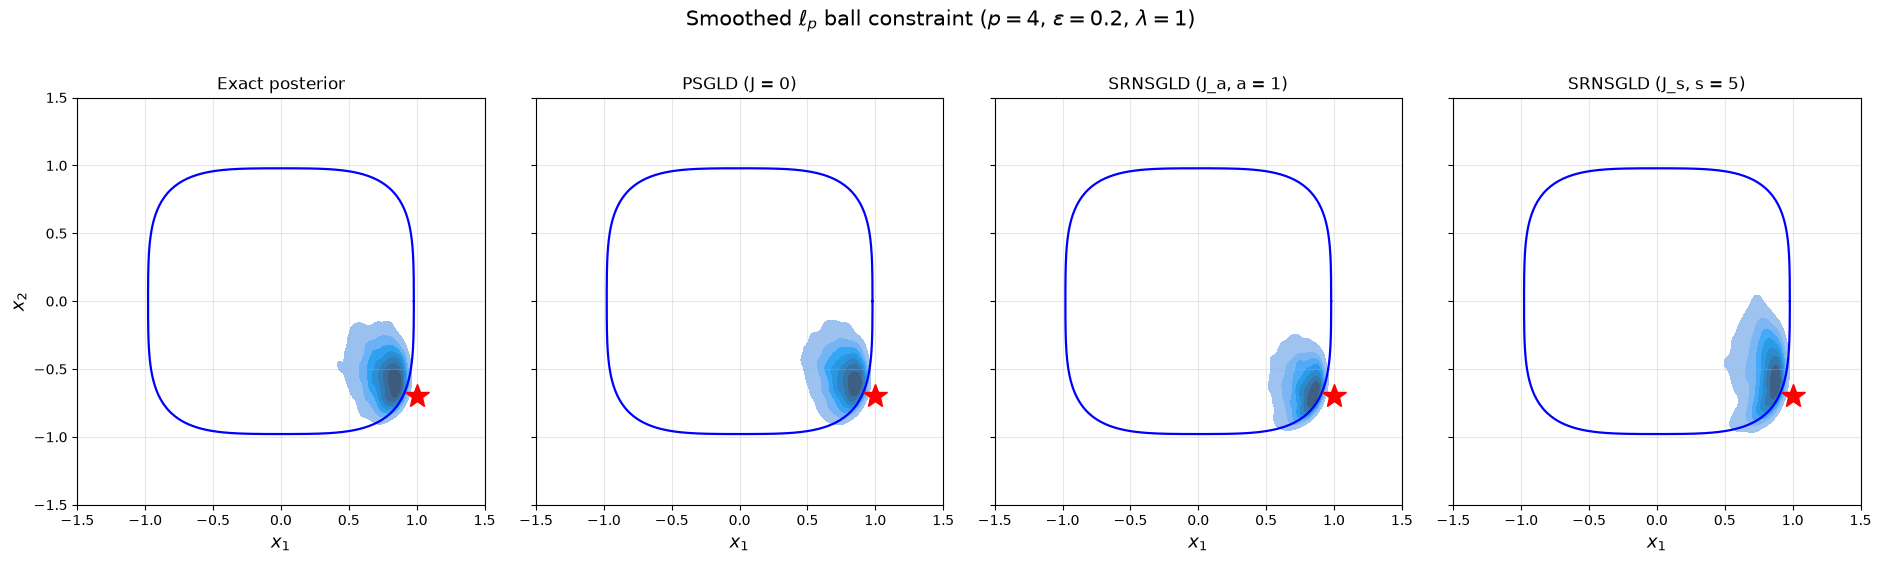

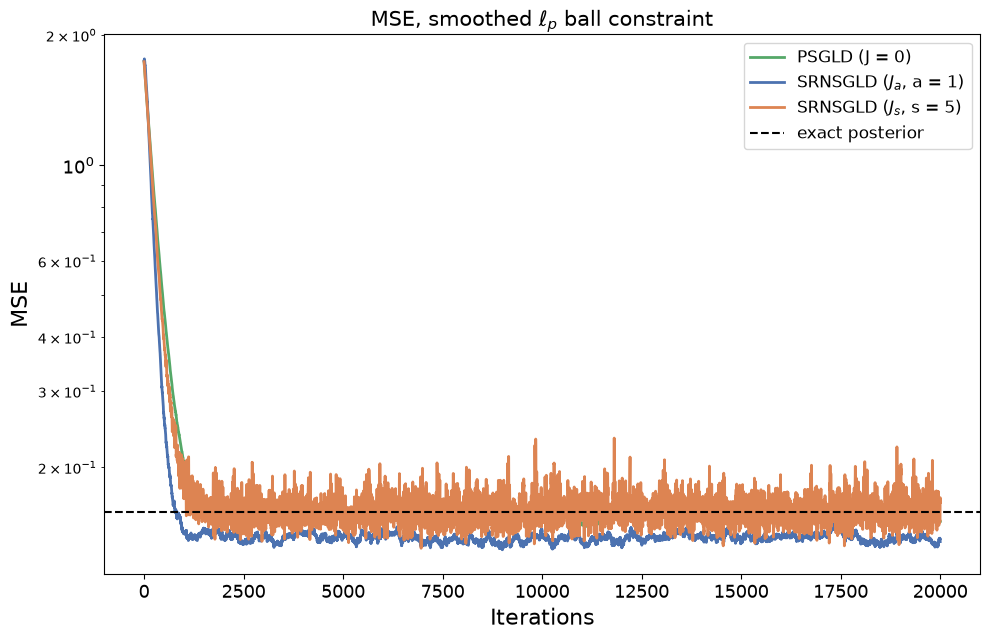

In [12]:
expLP = {}
for field, s, lab in METHODS:
    xf, W, mse = run_chain("lp", field, s, ref=refs["lp"])
    expLP[lab] = {"x": xf, "W1": W, "mse": mse}
    print("{:<26} MSE {:.4f}   W1 {}   on-boundary {:.3f}".format(
        lab.replace("$", ""), mse[-100:].mean(), np.round(W[-100:].mean(axis=0), 4), on_boundary("lp", xf)))
print("{:<26} MSE {:.4f}".format("exact posterior", mse_floor["lp"]))

th = np.linspace(0, 2 * np.pi, 400)
uu = np.stack([np.cos(th), np.sin(th), np.zeros_like(th)], 1)
lo, hi = np.zeros(len(th)), np.full(len(th), 5.0)
for _ in range(60):
    mid = (lo + hi) / 2
    over = g_lp(torch.tensor(uu * mid[:, None])).numpy() > LAM
    hi = np.where(over, mid, hi); lo = np.where(over, lo, mid)
bx, by = (lo + hi) / 2 * np.cos(th), (lo + hi) / 2 * np.sin(th)

fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=True, sharey=True)
panels = [("Exact posterior", refs["lp"])] + [(lab, expLP[lab]["x"]) for _, _, lab in METHODS]
for ax, (name, X) in zip(axes, panels):
    sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
    ax.plot(bx, by, "b-", linewidth=1.6)
    ax.plot([x_star[0]], [x_star[1]], "r*", markersize=18)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_title(name.replace("$", ""), fontsize=12); ax.set_xlabel("$x_1$", fontsize=13)
    ax.grid(True, alpha=0.3); ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("$x_2$", fontsize=13)
fig.suptitle(r"Smoothed $\ell_p$ ball constraint ($p=4$, $\varepsilon=0.2$, $\lambda=1$)", fontsize=15, y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("figures/blr_lp_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6.5))
for _, _, lab in METHODS:
    plt.plot(expLP[lab]["mse"], linewidth=2, color=COL[lab], label=lab)
plt.axhline(mse_floor["lp"], color="k", linestyle="--", linewidth=1.5, label="exact posterior")
plt.yscale("log"); plt.xlabel("Iterations", fontsize=16); plt.ylabel("MSE", fontsize=16)
plt.title(r"MSE, smoothed $\ell_p$ ball constraint", fontsize=15)
plt.tick_params(labelsize=13); plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/blr_lp_mse.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 5 — new: constrained Bayesian **Lasso**, where the anchoring matters

Everything above has a quadratic $U$, so $\Delta\equiv0$ and "anchored" adds nothing. Replacing the uniform
prior with a Laplace prior — the Bayesian Lasso, the $p=1$ case the paper cites as motivation for $\ell_p$
constraints — makes the potential non-differentiable on $d$ hyperplanes:

$$U(x)=\frac{\beta}{2n}\sum_j\bigl(y_j-x^\top a_j\bigr)^2+\frac{\lVert x\rVert_1}{b},\qquad b=0.5 .$$

The anchored scheme replaces the kinked term by its pseudo-Huber smoothing,
$U_0=\frac{\beta}{2n}\sum_j(\cdot)^2+\sum_i\sqrt{x_i^2+\delta^2}/b$, so $\nabla U$ is never evaluated,
$\Delta\in[-d\delta/b,0]$ needs no clamping, and the paper's $J_s$ rides on top unchanged.

In [13]:
B_PRIOR, DELTA_H = 0.5, 0.1

@torch.no_grad()
def U_lasso(x):   return torch.sum(torch.abs(x), dim=1) / B_PRIOR
@torch.no_grad()
def U0_lasso(x):  return torch.sum(torch.sqrt(x * x + DELTA_H ** 2), dim=1) / B_PRIOR
@torch.no_grad()
def gU0_lasso(x): return (x / torch.sqrt(x * x + DELTA_H ** 2)) / B_PRIOR

def run_lasso(field, s, eta=eta, n_steps=max_iter, N=N, ref=None, seed=SEED):
    torch.manual_seed(seed); gen = torch.Generator().manual_seed(seed)
    x = proj_ball(torch.zeros(N, d)); xs_t = torch.tensor(x_star)
    W, MSE = [], []
    for _it in range(n_steps):
        Delta = U_lasso(x) - U0_lasso(x)                      # in [-d*delta/b, 0]
        g = (grad_U_batch(x, gen) + gU0_lasso(x)) * torch.exp(Delta).unsqueeze(1)
        drift = g + skew_apply(x, g, field, s, "ball")
        x = proj_ball(x - eta * drift + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        MSE.append(float(torch.mean(torch.sum((x - xs_t) ** 2, dim=1))))
        if _it % TRACK_EVERY == 0:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), np.array(W), np.array(MSE)

# exact reference for the Lasso posterior: Gaussian proposal truncated to K, reweighted by the Laplace prior
def sample_lasso(n, rng):
    out = []
    while len(out) < n:
        z = mu_ols + rng.normal(size=(40000, d)) @ Lsig.T
        z = z[np.linalg.norm(z, axis=1) <= 1.0]
        w = np.exp(-(np.abs(z).sum(1) - 0.0) / B_PRIOR)       # ratio to the truncated Gaussian
        keep = z[rng.uniform(size=len(z)) < w]
        out.extend(keep.tolist())
    return np.array(out[:n])

ref_lasso = sample_lasso(N, rng)
floor_lasso = [float(np.mean([wasserstein_distance(ref_lasso[:, i], sample_lasso(N, rng)[:, i]) for _ in range(4)]))
               for i in range(d)]
mse_lasso = float(np.mean(np.sum((ref_lasso - x_star) ** 2, axis=1)))
print("Lasso posterior mean {}   W1 floor {}   MSE floor {:.4f}".format(
    np.round(ref_lasso.mean(0), 3), np.round(floor_lasso, 4), mse_lasso))

expLA = {}
for field, s, lab in METHODS:
    xf, W, mse = run_lasso(field, s, ref=ref_lasso)
    expLA[lab] = {"x": xf, "W1": W, "mse": mse}
    print("{:<26} MSE {:.4f}   W1 {}".format(lab.replace("$", ""), mse[-100:].mean(), np.round(W[-100:].mean(axis=0), 4)))

Lasso posterior mean [ 0.593 -0.461 -0.323]   W1 floor [0.0034 0.0036 0.0058]   MSE floor 0.3194


PSGLD (J = 0)              MSE 0.3086   W1 [0.0064 0.0046 0.0086]


SRNSGLD (J_a, a = 1)       MSE 0.2803   W1 [0.0209 0.1061 0.0727]


SRNSGLD (J_s, s = 5)       MSE 0.2991   W1 [0.0222 0.0263 0.0253]


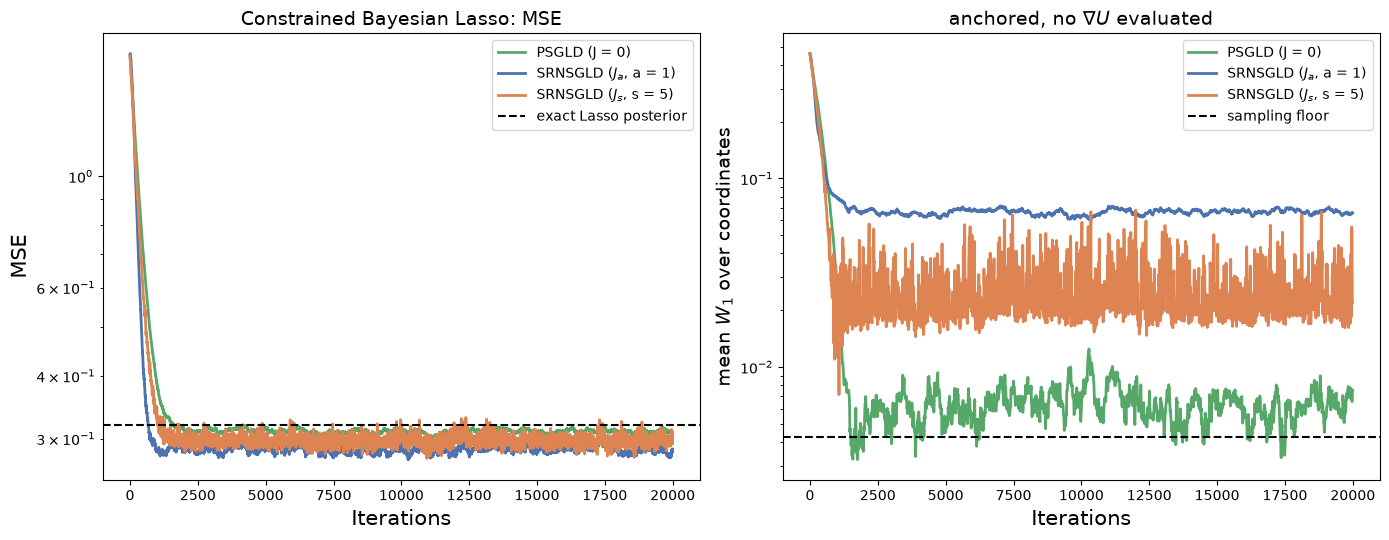

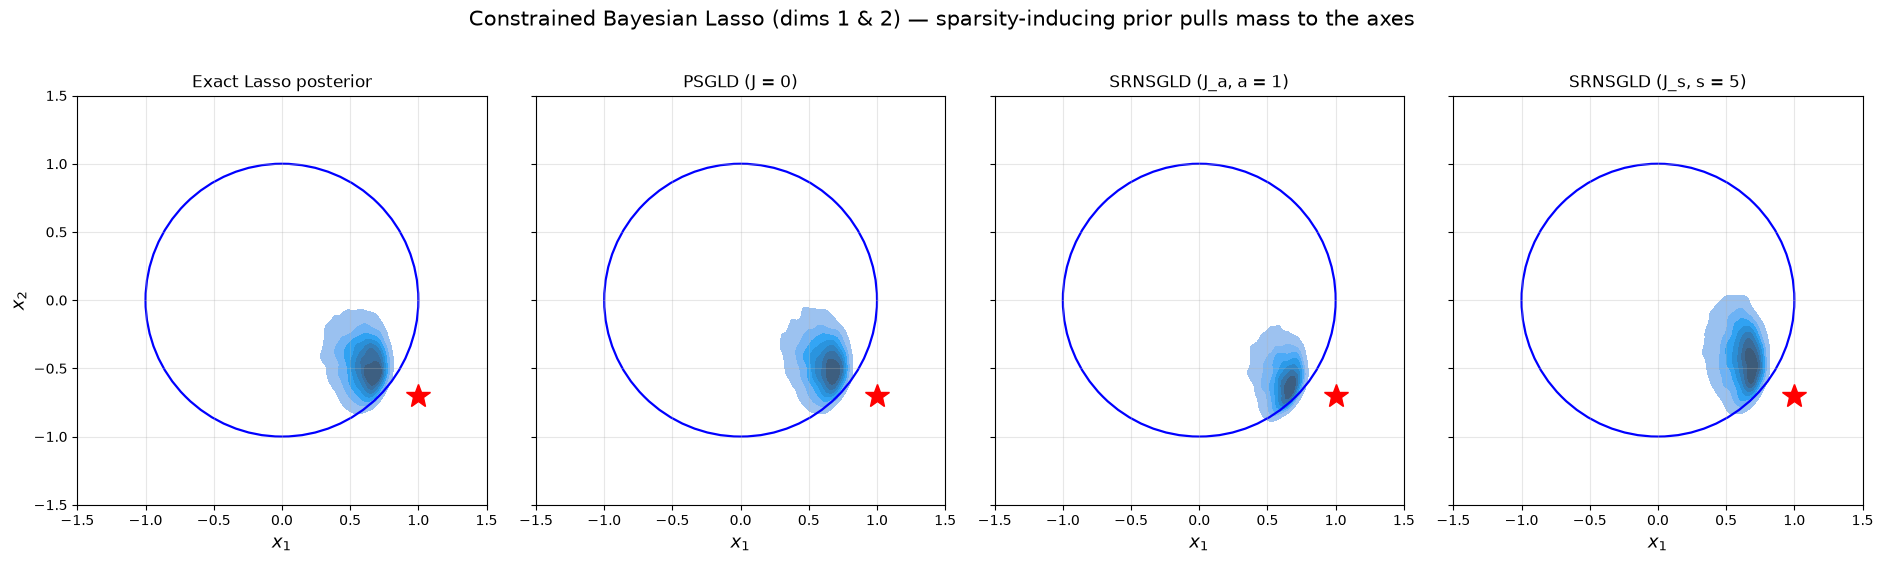

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for _, _, lab in METHODS:
    axes[0].plot(expLA[lab]["mse"], linewidth=2, color=COL[lab], label=lab)
axes[0].axhline(mse_lasso, color="k", linestyle="--", linewidth=1.5, label="exact Lasso posterior")
axes[0].set_yscale("log"); axes[0].set_xlabel("Iterations", fontsize=15); axes[0].set_ylabel("MSE", fontsize=15)
axes[0].set_title("Constrained Bayesian Lasso: MSE", fontsize=14); axes[0].legend(fontsize=10)
for _, _, lab in METHODS:
    axes[1].plot(np.arange(len(expLA[lab]["W1"]))*TRACK_EVERY, expLA[lab]["W1"].mean(axis=1), linewidth=2, color=COL[lab], label=lab)
axes[1].axhline(np.mean(floor_lasso), color="k", linestyle="--", linewidth=1.5, label="sampling floor")
axes[1].set_yscale("log"); axes[1].set_xlabel("Iterations", fontsize=15)
axes[1].set_ylabel("mean $W_1$ over coordinates", fontsize=14)
axes[1].set_title("anchored, no $\\nabla U$ evaluated", fontsize=14); axes[1].legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/blr_lasso.pdf", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=True, sharey=True)
panels = [("Exact Lasso posterior", ref_lasso)] + [(lab, expLA[lab]["x"]) for _, _, lab in METHODS]
for ax, (name, X) in zip(axes, panels):
    sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
    ax.add_patch(Circle((0, 0), np.sqrt(LAM), edgecolor="b", facecolor="none", linewidth=1.6))
    ax.plot([x_star[0]], [x_star[1]], "r*", markersize=18)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_title(name.replace("$", ""), fontsize=12); ax.set_xlabel("$x_1$", fontsize=13)
    ax.grid(True, alpha=0.3); ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("$x_2$", fontsize=13)
fig.suptitle("Constrained Bayesian Lasso (dims 1 & 2) — sparsity-inducing prior pulls mass to the axes",
             fontsize=15, y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("figures/blr_lasso_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 6 — new: the skew strength and the stepsize are not independent

A tangential drift is exactly what the boundary condition asks for in *continuous* time, but an Euler step
moves along the tangent **line**, which leaves the sphere: $\lVert x+\epsilon v\rVert>\lVert x\rVert$ for any
$v\perp x$. The projection then puts the particle back on $\partial K$. The size of that overshoot is
$O(\eta^2\lVert J\nabla U\rVert^2)$ per step, so a large skew strength manufactures a boundary atom out of
nothing unless $\eta$ is reduced to match.

This bites hard here because the posterior is sharp: $\lVert\nabla U\rVert\sim\beta\lambda_{\max}(H)\approx400$,
against $O(1)$ in the earlier Laplace notebooks. At $\eta=10^{-3}$ the $s=5$ field drives $92\%$ of the
ensemble onto the boundary against a true $0.4\%$. The table below is the reason this notebook runs at the
paper's $\eta=10^{-4}$.

In [15]:
print("{:<26}{:>10}{:>16}{:>16}{:>14}".format("method", "eta", "MSE", "mean W1", "on boundary"))
print("-" * 84)
stab = {}
for eta_r, n_r in [(1e-3, 2000), (3e-4, 7000), (1e-4, 20000)]:
    for field, s, lab in METHODS:
        xf, _, mse = run_chain("ball", field, s, eta=eta_r, n_steps=n_r, ref=refs["ball"], track=False)
        w = float(np.mean([wasserstein_distance(refs["ball"][:, i], xf[:, i]) for i in range(d)]))
        stab[(eta_r, lab)] = (mse[-100:].mean(), w, on_boundary("ball", xf))
        print("{:<26}{:>10}{:>16.4f}{:>16.4f}{:>14.3f}".format(lab.replace("$", ""), eta_r, *stab[(eta_r, lab)]))
print("{:<26}{:>10}{:>16.4f}{:>16.4f}{:>14.3f}".format(
    "exact posterior", "-", mse_floor["ball"], float(np.mean(floors["ball"])), on_boundary("ball", refs["ball"])))

method                           eta             MSE         mean W1   on boundary
------------------------------------------------------------------------------------


PSGLD (J = 0)                  0.001          0.2473          0.0140         0.217


SRNSGLD (J_a, a = 1)           0.001          0.2523          0.0960         0.303


SRNSGLD (J_s, s = 5)           0.001          0.8390          0.2966         0.873


PSGLD (J = 0)                 0.0003          0.2495          0.0097         0.116


SRNSGLD (J_a, a = 1)          0.0003          0.2547          0.0947         0.215


SRNSGLD (J_s, s = 5)          0.0003          0.2943          0.1164         0.286


PSGLD (J = 0)                 0.0001          0.2580          0.0056         0.074


SRNSGLD (J_a, a = 1)          0.0001          0.2588          0.0919         0.149


SRNSGLD (J_s, s = 5)          0.0001          0.2591          0.0579         0.094
exact posterior                    -          0.2639          0.0029         0.004


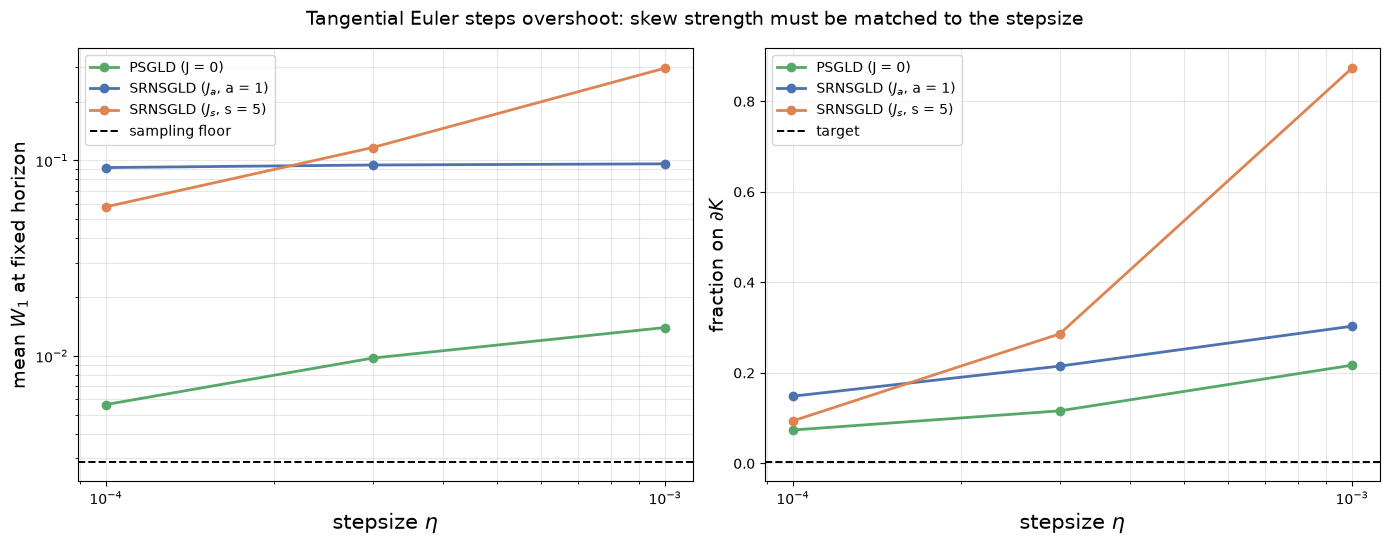

In [16]:
etas_s = [1e-3, 3e-4, 1e-4]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for _, _, lab in METHODS:
    axes[0].plot(etas_s, [stab[(e, lab)][1] for e in etas_s], "-o", linewidth=2, color=COL[lab], label=lab)
    axes[1].plot(etas_s, [stab[(e, lab)][2] for e in etas_s], "-o", linewidth=2, color=COL[lab], label=lab)
axes[0].axhline(np.mean(floors["ball"]), color="k", linestyle="--", linewidth=1.4, label="sampling floor")
axes[1].axhline(on_boundary("ball", refs["ball"]), color="k", linestyle="--", linewidth=1.4, label="target")
for ax, yl in zip(axes, ["mean $W_1$ at fixed horizon", r"fraction on $\partial K$"]):
    ax.set_xscale("log"); ax.set_xlabel(r"stepsize $\eta$", fontsize=15); ax.set_ylabel(yl, fontsize=14)
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=10)
axes[0].set_yscale("log")
fig.suptitle("Tangential Euler steps overshoot: skew strength must be matched to the stepsize", fontsize=14)
plt.tight_layout()
plt.savefig("figures/blr_stability.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**Setup.** The paper's Eq. (3.8) data ($n=10^5$, $m=50$, $x_*=[1,-0.7,-0.5]$ with $\lVert x_*\rVert=1.32$,
so the truth is outside $K$), their $J_a$ with $a=1$ and $J_s$ with $s=5$, their stepsize $\eta=10^{-4}$,
run to $2\times10^4$ iterations. Temperature $\beta=32$, chosen in Experiment 2: at $\beta=1$ the constrained
mean is $[0.07,-0.11,-0.11]$ against a truth of $[1,-0.7,-0.5]$ (the data is washed out) and at $\beta=n$
the posterior is a point mass. An exact reference is available by rejection, so both MSE and $W_1$ are
reported.

**MSE — the paper's metric — cannot separate the methods here.** All three land within $0.5\%$ of each
other and of the floor: $0.2580$ (PSGLD), $0.2588$ ($J_a$), $0.2591$ ($J_s$), against an exact-posterior
value of $0.2639$. That is not a null result about the samplers, it is a statement about the metric: since
$x_*\notin K$, MSE is dominated by the fixed $\lVert\text{proj}(x_*)-x_*\rVert^2$ offset and is nearly blind
to the shape of the sampled law.

**$W_1$ and boundary mass do separate them** (ball, floor $[0.0029,0.0026,0.0032]$, target boundary mass
$0.4\%$):

| method | $W_1$ | on $\partial K$ |
|---|---|---|
| PSGLD ($J=0$) | $(0.0045,0.0041,0.0050)$ | 7.4% |
| SRNSGLD ($J_a$, $a=1$) | $(0.013,\mathbf{0.144},\mathbf{0.121})$ | 14.9% |
| SRNSGLD ($J_s$, $s=5$) | $(0.014,0.028,0.028)$ | 9.4% |

$J_a$ is off by a factor of $50$ on coordinates 2 and 3 — the boundary-condition violation, now visible on
a completely different target. The $W_1$ traces show it plateauing from iteration $\approx500$ onward and
never improving.

**Experiment 6 is the sharpest result in this notebook.** Refining $\eta$ at matched physical horizon:

| $\eta$ | PSGLD | $J_a$ ($a=1$) | $J_s$ ($s=5$) |
|---|---|---|---|
| $10^{-3}$ | 0.0140 / 21.7% | 0.0960 / 30.3% | 0.2966 / 87.3% |
| $3\times10^{-4}$ | 0.0097 / 11.6% | 0.0947 / 21.5% | 0.1164 / 28.6% |
| $10^{-4}$ | 0.0056 / 7.4% | **0.0919** / 14.9% | 0.0579 / 9.4% |

(mean $W_1$ / boundary fraction). The two failure modes are cleanly separated: $J_a$'s error is **flat in
$\eta$** — $0.096\to0.095\to0.092$, an irreducible bias from $J n\neq0$ that no stepsize fixes — while
$J_s$'s error **falls by $5\times$** as $\eta$ shrinks, because it is pure discretization. Note the
crossover: at $\eta=10^{-3}$ the admissible field is *worse* than the inadmissible one ($0.297$ vs $0.096$,
with $87\%$ of the ensemble pinned to the boundary), which is exactly the trap this experiment fell into
before being re-run at the paper's stepsize. A tangential drift is tangential to the *sphere*, but an Euler
step follows the tangent *line* and leaves it, by $O(\eta^2\lVert J\nabla U\rVert^2)$ per step. With
$\lVert\nabla U\rVert\sim\beta\lambda_{\max}(H)\approx400$ here against $O(1)$ in the Laplace notebooks, the
same $s=5$ that was harmless there is destructive at $\eta=10^{-3}$.

**No acceleration is visible in this experiment,** and the reason is structural: the chain reaches
stationarity in roughly $500$ of $2\times10^4$ iterations, so $97\%$ of every trace is stationary behaviour,
where $J$ can only add error. The transient is too short to resolve at this scale — for where the
acceleration does live, see `anchored_langevin_paper_J.ipynb`, Experiment 4.

**Minibatching is not the issue.** $m=50$ against the full $n=10^5$ gradient changes MSE by less than
$0.3\%$ for every method ($0.2580$ vs $0.2584$ for PSGLD), so everything above is about the dynamics, not
the gradient noise.

**Anchoring earns its place only in Experiment 5.** With a quadratic $U$ the anchor recipe returns $U_0=U$
and $\Delta\equiv0$, so "anchored" is just SGLD here. Adding a Laplace prior (Bayesian Lasso, $b=0.5$) makes
$U$ non-differentiable on $d$ hyperplanes; the pseudo-Huber anchor then samples it without ever evaluating
$\nabla U$, reaching $W_1=(0.0064,0.0046,0.0086)$ against a floor of $(0.0034,0.0036,0.0058)$, with the
paper's $J_s$ riding on top unchanged and the same $J_a$-vs-$J_s$ ordering as everywhere else.